# Multimodal AutoML LOOCV — Morph PCA(3) + FC strength (SHAP Top-2)

`automl_comparison_paired_all_PCA.ipynb`(morph)와 `automl_comparison_paired_FC_SHAP_top2_strength.ipynb`(FC)를
**하나의 파이프라인에서 결합**한다. AutoML 6개 모델 · LOOCV · nested GridSearchCV는 그대로.

## 표본
- morph 45명 ∩ FC 44명 = **공통 44명** (morph 단독의 rid=1 제외). Active 25 / Sham 19.
- 타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 뇌 피처 | 개수 |
|---|---|---|
| `Clinical_ONLY` | 없음 | 2 |
| `Morph_PCA3` | morph 152 → fold내 PCA 3성분 | 2+3 |
| `FC_PCA3` | FC strength 84 → fold내 PCA 3성분 | 2+3 |
| `Multimodal_expl` | morph PCA3 + **FC SHAP Top-2** (`rh_Pallidum_fc`, `lh_cuneus_fc`) | 2+3+2 |
| `Multimodal_def` | morph PCA3 + FC PCA3 | 2+3+3 |

## nuisance (모달리티별로 따로, fold내 train에서만 fit)
- morph 피처 ← `age`, `sex`, `eTIV`
- FC 피처 ← `age`, `sex`, `mean_fd`

## ⚠️ leakage 경고
`Multimodal_expl`의 FC 2개(`rh_Pallidum_fc`, `lh_cuneus_fc`)는 **같은 44명의 SHAP**으로 고른 것이다.
→ 이 조합이 좋아 보여도 unbiased 아님. **정직한 비교는 `Multimodal_def` vs `Morph_PCA3`**.
`Multimodal_expl`은 탐색적 상한선으로만 본다.


In [1]:
import os, tempfile
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피
_tmp = os.path.join(os.environ.get('LOCALAPPDATA', tempfile.gettempdir()), 'joblib_tms_tmp')
os.makedirs(_tmp, exist_ok=True)
os.environ['JOBLIB_TEMP_FOLDER'] = _tmp

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (morph 152 + FC strength 84, rid 기준 결합)
# ==========================================================
morph = pd.read_csv('structural_full_68_68_16_edited.csv', skipinitialspace=True)
morph.columns = morph.columns.str.strip()
fc = pd.read_csv('fc_strength_68_16.csv', skipinitialspace=True)
fc.columns = fc.columns.str.strip()

morph_features   = morph.columns[7:].tolist()   # 152개 (앞 7열 = rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV)
fc_strength_cols = fc.columns[7:].tolist()      # 84개  (앞 7열 = ... mean_fd)
FC_TOP2 = ['rh_Pallidum_fc', 'lh_cuneus_fc']    # SHAP Top-2 (automl_comparison_paired_FC_all_SHAP_bg43.ipynb 결과)

assert len(morph_features) == 152, len(morph_features)
assert len(fc_strength_cols) == 84, len(fc_strength_cols)
assert all(c in fc_strength_cols for c in FC_TOP2)

# --- rid inner join: 공통 44명 (morph 단독 rid=1 제외) ---
fc_ren = fc.rename(columns={c: f'{c}__fc' for c in fc.columns if c != 'rid'})
df = morph.merge(fc_ren, on='rid', how='inner').reset_index(drop=True)
assert len(df) == 44, len(df)

# 임상/공변량(age, sex, vas_t0, vas_t1, treatment_group)은 두 파일이 44명에서 완전히 일치 → morph 쪽 사용
X_morph      = df[morph_features].values                            # (44, 152)
X_fc_top2    = df[[f'{c}__fc' for c in FC_TOP2]].values              # (44, 2)
X_fc_all     = df[[f'{c}__fc' for c in fc_strength_cols]].values     # (44, 84)
X_nuis_morph = df[['age', 'sex', 'eTIV']].values
X_nuis_fc    = df[['age', 'sex', 'mean_fd__fc']].values
X_clinical   = df[['vas_t0', 'treatment_group']].values
y            = df['vas_t1'].values
group        = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'morph {X_morph.shape[1]} | FC strength {X_fc_all.shape[1]} | FC Top-2 {FC_TOP2}')

n = 44  |  Active 25 / Sham 19
morph 152 | FC strength 84 | FC Top-2 ['rh_Pallidum_fc', 'lh_cuneus_fc']


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA_MORPH = 3   # morph 152 → 3성분 (morph 단독 최적: automl_comparison_paired_all_PCA.ipynb)
N_PCA_FC    = 3   # FC strength 84 → 3성분 (defensible 버전)

DATA_TYPES = ['Clinical_ONLY', 'Morph_PCA3', 'FC_PCA3', 'Multimodal_expl', 'Multimodal_def']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 모달리티별 nuisance residualization → (morph / FC-all) PCA → stack → StandardScaler
#    ※ 5 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []
evr_morph_log, evr_fc_log = [], []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_morph)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr, y_te = y[tr], y[te]
    y_true.append(y_te[0])

    # ---- morph: residualize(age, sex, eTIV) → scale → PCA(N_PCA_MORPH) ----
    r_m = LinearRegression().fit(X_nuis_morph[tr], X_morph[tr])
    Xm_tr = X_morph[tr] - r_m.predict(X_nuis_morph[tr])
    Xm_te = X_morph[te] - r_m.predict(X_nuis_morph[te])
    sc_m = StandardScaler().fit(Xm_tr)
    pca_m = PCA(n_components=N_PCA_MORPH, random_state=42).fit(sc_m.transform(Xm_tr))
    Xm_tr_p = pca_m.transform(sc_m.transform(Xm_tr))
    Xm_te_p = pca_m.transform(sc_m.transform(Xm_te))
    evr_morph_log.append(pca_m.explained_variance_ratio_.sum())

    # ---- FC Top-2: residualize(age, sex, mean_fd) 만 (SHAP top2 노트북과 동일) ----
    r_f2 = LinearRegression().fit(X_nuis_fc[tr], X_fc_top2[tr])
    Xf2_tr = X_fc_top2[tr] - r_f2.predict(X_nuis_fc[tr])
    Xf2_te = X_fc_top2[te] - r_f2.predict(X_nuis_fc[te])

    # ---- FC all 84: residualize → scale → PCA(N_PCA_FC) ----
    r_f = LinearRegression().fit(X_nuis_fc[tr], X_fc_all[tr])
    Xf_tr = X_fc_all[tr] - r_f.predict(X_nuis_fc[tr])
    Xf_te = X_fc_all[te] - r_f.predict(X_nuis_fc[te])
    sc_f = StandardScaler().fit(Xf_tr)
    pca_f = PCA(n_components=N_PCA_FC, random_state=42).fit(sc_f.transform(Xf_tr))
    Xf_tr_p = pca_f.transform(sc_f.transform(Xf_tr))
    Xf_te_p = pca_f.transform(sc_f.transform(Xf_te))
    evr_fc_log.append(pca_f.explained_variance_ratio_.sum())

    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY':   (Xc_tr, Xc_te),
        'Morph_PCA3':      (np.hstack([Xm_tr_p, Xc_tr]),           np.hstack([Xm_te_p, Xc_te])),
        'FC_PCA3':         (np.hstack([Xf_tr_p, Xc_tr]),           np.hstack([Xf_te_p, Xc_te])),
        'Multimodal_expl': (np.hstack([Xm_tr_p, Xf2_tr, Xc_tr]),   np.hstack([Xm_te_p, Xf2_te, Xc_te])),
        'Multimodal_def':  (np.hstack([Xm_tr_p, Xf_tr_p, Xc_tr]),  np.hstack([Xm_te_p, Xf_te_p, Xc_te])),
    }

    for dt in DATA_TYPES:
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")
print(f"morph PCA{N_PCA_MORPH} 누적 설명분산 평균: {np.mean(evr_morph_log):.1%}  |  "
      f"FC PCA{N_PCA_FC} 누적 설명분산 평균: {np.mean(evr_fc_log):.1%}")

Starting LOOCV: 6 models x 5 datasets x 44 folds ...





LOOCV done.
morph PCA3 누적 설명분산 평균: 36.8%  |  FC PCA3 누적 설명분산 평균: 76.5%


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
ov['d_expl_vs_Clinical']  = ov['Clinical_ONLY'] - ov['Multimodal_expl']
ov['d_expl_vs_MorphPCA3'] = ov['Morph_PCA3']    - ov['Multimodal_expl']
ov['d_def_vs_MorphPCA3']  = ov['Morph_PCA3']    - ov['Multimodal_def']
print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,Morph_PCA3,FC_PCA3,Multimodal_expl,Multimodal_def,d_expl_vs_Clinical,d_expl_vs_MorphPCA3,d_def_vs_MorphPCA3
Model,,,,,,,,
LinearRegression,1.997,1.978,2.013,1.958,1.986,0.039,0.020,-0.008
ElasticNet,1.996,1.968,2.082,1.929,1.945,0.067,0.038,0.022
SVR_Linear,2.041,1.975,1.953,2.094,2.068,-0.053,-0.119,-0.093
SVR_RBF,2.208,2.041,2.118,2.094,2.067,0.114,-0.053,-0.025
RandomForest,2.201,2.412,2.290,2.341,2.406,-0.140,0.071,0.005
XGBoost,2.235,2.424,2.311,2.354,2.574,-0.119,0.070,-0.150



========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,Multimodal_expl,ElasticNet,1.9294,0.2691,0.5314,0.0002
1,Multimodal_def,ElasticNet,1.9454,0.2570,0.5549,0.0001
2,FC_PCA3,SVR_Linear,1.9533,0.2509,0.5177,0.0003
3,Multimodal_expl,LinearRegression,1.9582,0.2472,0.5379,0.0002
4,Morph_PCA3,ElasticNet,1.9676,0.2399,0.4970,0.0006
5,Morph_PCA3,SVR_Linear,1.9747,0.2344,0.4962,0.0006
6,Morph_PCA3,LinearRegression,1.9778,0.2320,0.5082,0.0004
7,Multimodal_def,LinearRegression,1.9860,0.2256,0.5106,0.0004
8,Clinical_ONLY,ElasticNet,1.9962,0.2176,0.4778,0.0010
9,Clinical_ONLY,LinearRegression,1.9973,0.2167,0.4784,0.0010


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))

print("\n===== Multimodal 상세 (Morph_PCA3 / Multimodal_expl / Multimodal_def) =====")
show = res[res['Data Type'].isin(['Morph_PCA3', 'Multimodal_expl', 'Multimodal_def'])].copy()
show['Data Type'] = pd.Categorical(show['Data Type'],
                                   ['Morph_PCA3', 'Multimodal_expl', 'Multimodal_def'])
show['Model'] = pd.Categorical(show['Model'], list(models))
display(show.sort_values(['Data Type', 'Model', 'Scope'])
        .set_index(['Data Type', 'Model', 'Scope'])[['RMSE', 'R2', 'r', 'p']].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,Morph_PCA3,FC_PCA3,Multimodal_expl,Multimodal_def
Model,,,,,
LinearRegression,1.997,1.978,2.013,1.958,1.986
ElasticNet,1.996,1.968,2.082,1.929,1.945
SVR_Linear,2.041,1.975,1.953,2.094,2.068
SVR_RBF,2.208,2.041,2.118,2.094,2.067
RandomForest,2.201,2.412,2.290,2.341,2.406
XGBoost,2.235,2.424,2.311,2.354,2.574



===== Active  RMSE =====


Data Type,Clinical_ONLY,Morph_PCA3,FC_PCA3,Multimodal_expl,Multimodal_def
Model,,,,,
LinearRegression,2.004,2.124,2.000,2.090,2.087
ElasticNet,2.003,2.089,2.075,2.038,1.965
SVR_Linear,2.055,2.164,1.952,2.327,2.180
SVR_RBF,2.291,2.182,2.130,2.216,2.170
RandomForest,2.261,2.702,2.440,2.601,2.658
XGBoost,2.341,2.670,2.396,2.528,2.848



===== Sham  RMSE =====


Data Type,Clinical_ONLY,Morph_PCA3,FC_PCA3,Multimodal_expl,Multimodal_def
Model,,,,,
LinearRegression,1.989,1.766,2.029,1.770,1.845
ElasticNet,1.988,1.795,2.090,1.776,1.919
SVR_Linear,2.022,1.693,1.955,1.739,1.910
SVR_RBF,2.095,1.840,2.103,1.924,1.922
RandomForest,2.118,1.966,2.077,1.947,2.028
XGBoost,2.089,2.056,2.195,2.103,2.162



===== Multimodal 상세 (Morph_PCA3 / Multimodal_expl / Multimodal_def) =====


RMSE     R2      r      p
Data Type       Model            Scope                              
Morph_PCA3      LinearRegression Active   2.124  0.153  0.444  0.026
                                 Overall  1.978  0.232  0.508  0.000
                                 Sham     1.766  0.326  0.581  0.009
                ElasticNet       Active   2.089  0.180  0.447  0.025
                                 Overall  1.968  0.240  0.497  0.001
                                 Sham     1.795  0.304  0.554  0.014
                SVR_Linear       Active   2.164  0.120  0.398  0.049
                                 Overall  1.975  0.234  0.496  0.001
                                 Sham     1.693  0.381  0.620  0.005
                SVR_RBF          Active   2.182  0.107  0.416  0.038
                                 Overall  2.041  0.182  0.456  0.002
                                 Sham     1.840  0.268  0.523  0.022
                RandomForest     Active   2.702 -0.370  0.090  0.667
                                 Overall  2.412 -0.142  0.184  0.233
                                 Sham     1.966  0.165  0.484  0.036
                XGBoost          Active   2.670 -0.338  0.115  0.584
                                 Overall  2.424 -0.153  0.214  0.163
                                 Sham     2.056  0.087  0.401  0.089
Multimodal_expl LinearRegression Active   2.090  0.180  0.486  0.014
                                 Overall  1.958  0.247  0.538  0.000
                                 Sham     1.770  0.323  0.593  0.007
                ElasticNet       Active   2.038  0.220  0.490  0.013
                                 Overall  1.929  0.269  0.531  0.000
                                 Sham     1.776  0.318  0.573  0.010
                SVR_Linear       Active   2.327 -0.017  0.330  0.107
                                 Overall  2.094  0.139  0.439  0.003
                                 Sham     1.739  0.347  0.597  0.007
                SVR_RBF          Active   2.216  0.078  0.370  0.069
                                 Overall  2.094  0.139  0.418  0.005
                                 Sham     1.924  0.201  0.468  0.043
                RandomForest     Active   2.601 -0.270  0.143  0.497
                                 Overall  2.341 -0.076  0.220  0.151
                                 Sham     1.947  0.181  0.497  0.030
                XGBoost          Active   2.528 -0.200  0.108  0.606
                                 Overall  2.354 -0.088  0.184  0.232
                                 Sham     2.103  0.045  0.382  0.106
Multimodal_def  LinearRegression Active   2.087  0.182  0.464  0.020
                                 Overall  1.986  0.226  0.511  0.000
                                 Sham     1.845  0.265  0.558  0.013
                ElasticNet       Active   1.965  0.275  0.602  0.001
                                 Overall  1.945  0.257  0.555  0.000
                                 Sham     1.919  0.204  0.488  0.034
                SVR_Linear       Active   2.180  0.108  0.340  0.096
                                 Overall  2.068  0.161  0.408  0.006
                                 Sham     1.910  0.212  0.513  0.025
                SVR_RBF          Active   2.170  0.116  0.366  0.072
                                 Overall  2.067  0.161  0.416  0.005
                                 Sham     1.922  0.202  0.465  0.045
                RandomForest     Active   2.658 -0.327  0.054  0.799
                                 Overall  2.406 -0.137  0.137  0.376
                                 Sham     2.028  0.112  0.451  0.053
                XGBoost          Active   2.848 -0.523  0.029  0.890
                                 Overall  2.574 -0.301  0.059  0.705
                                 Sham     2.162 -0.010  0.232  0.339

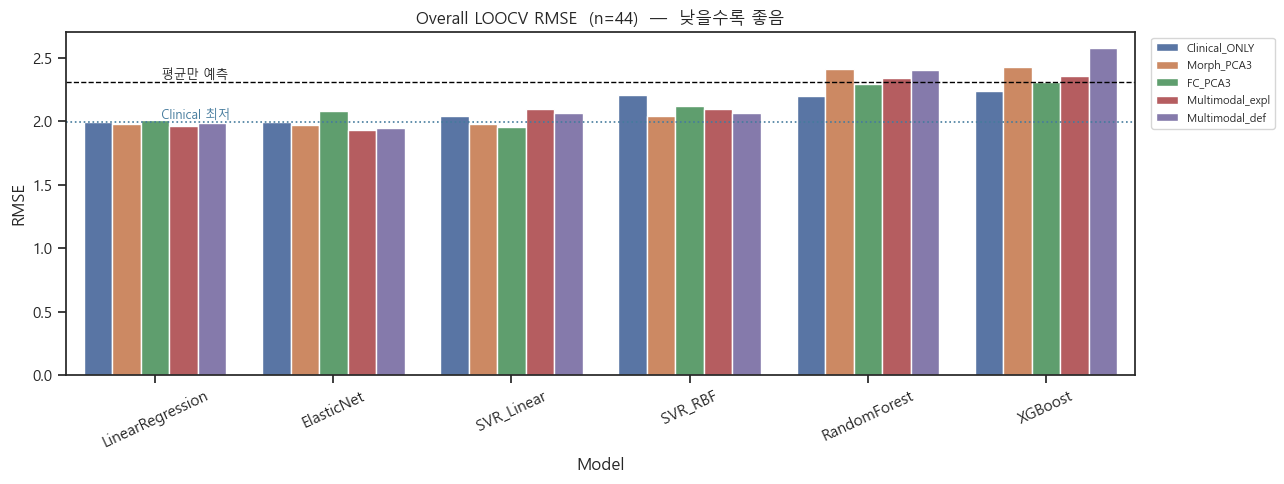

In [7]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[Morph_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[Morph_PCA3 / ElasticNet] 고유 7개, 최빈 34%   <-- 불안정
[Morph_PCA3 / SVR_Linear] 고유 6개, 최빈 36%   <-- 불안정
[Morph_PCA3 / SVR_RBF] 고유 7개, 최빈 73%
[Morph_PCA3 / RandomForest] 고유 10개, 최빈 45%   <-- 불안정
[Morph_PCA3 / XGBoost] 고유 7개, 최빈 75%
[FC_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[FC_PCA3 / ElasticNet] 고유 6개, 최빈 36%   <-- 불안정
[FC_PCA3 / SVR_Linear] 고유 12개, 최빈 23%   <-- 불안정
[FC_PCA3 / SVR_RBF] 고유 15개, 최빈 30%   <-- 불안정
[FC_PCA3 / RandomForest] 고유 7개, 최빈 84%
[FC_PCA3 / XGBoost] 고유 9개, 최빈 36%   <-- 불안정
[Multimodal_expl / LinearRegression] 고유 1개, 최빈 100%
[Multimodal_expl / ElasticNet] 고유 3개, 최빈 93%
[Multimodal_expl / SVR_Linear] 고유 9개, 최빈 36%   <-- 불안정
[Multimodal_expl / SVR_RBF] 고유 12개

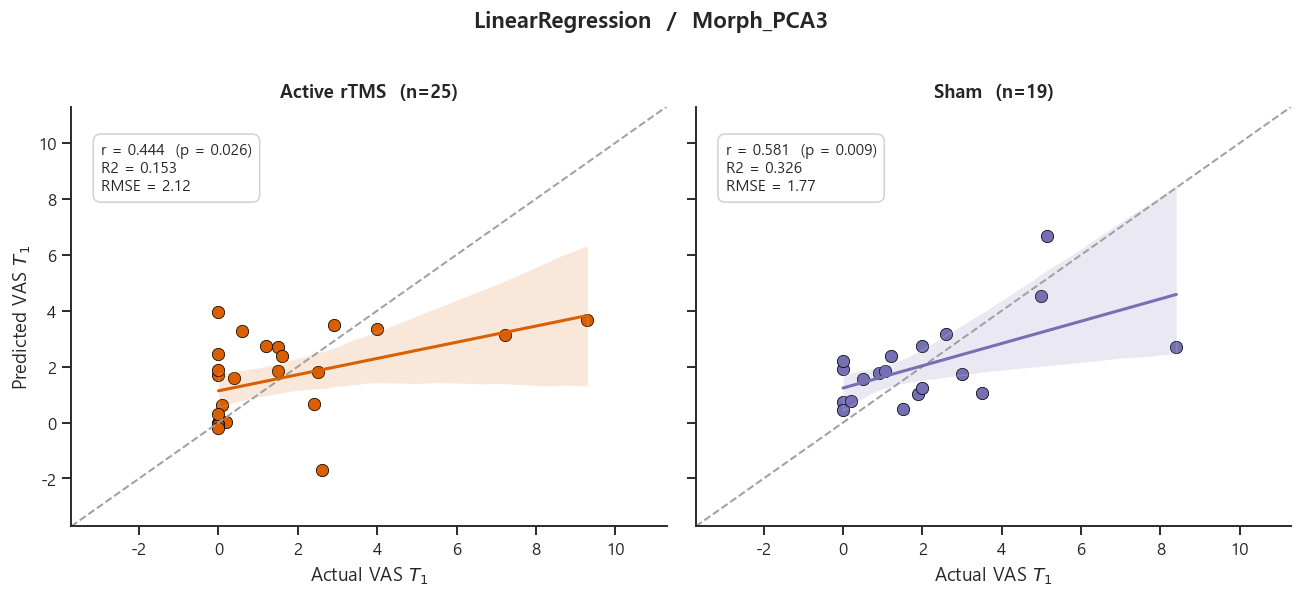

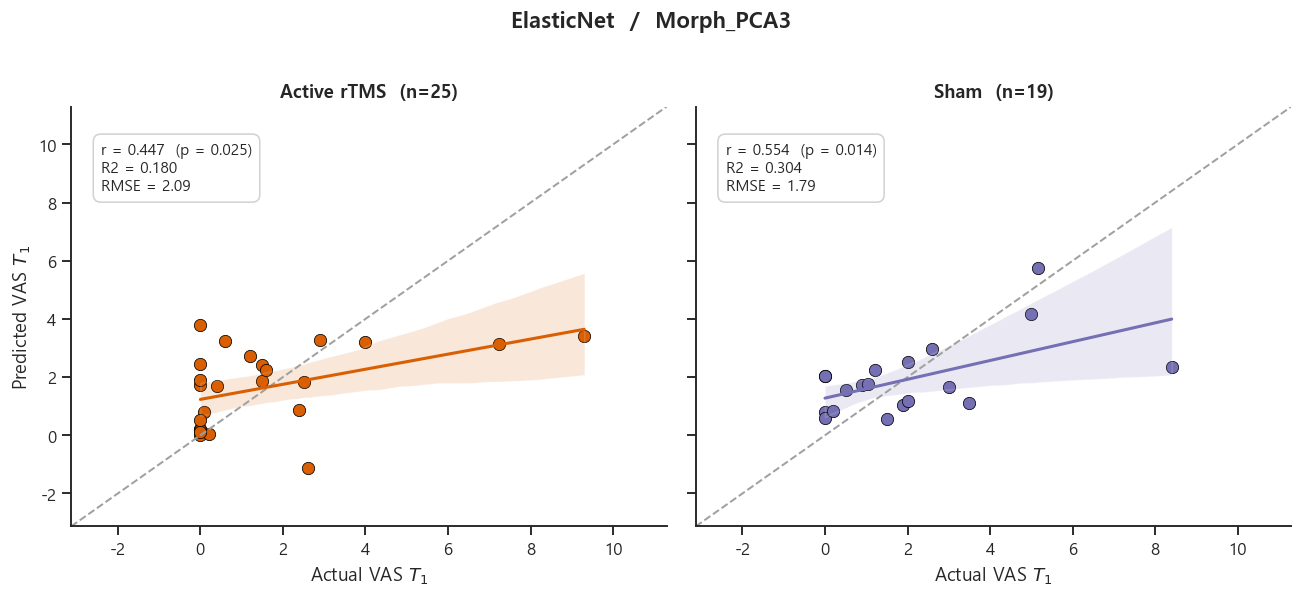

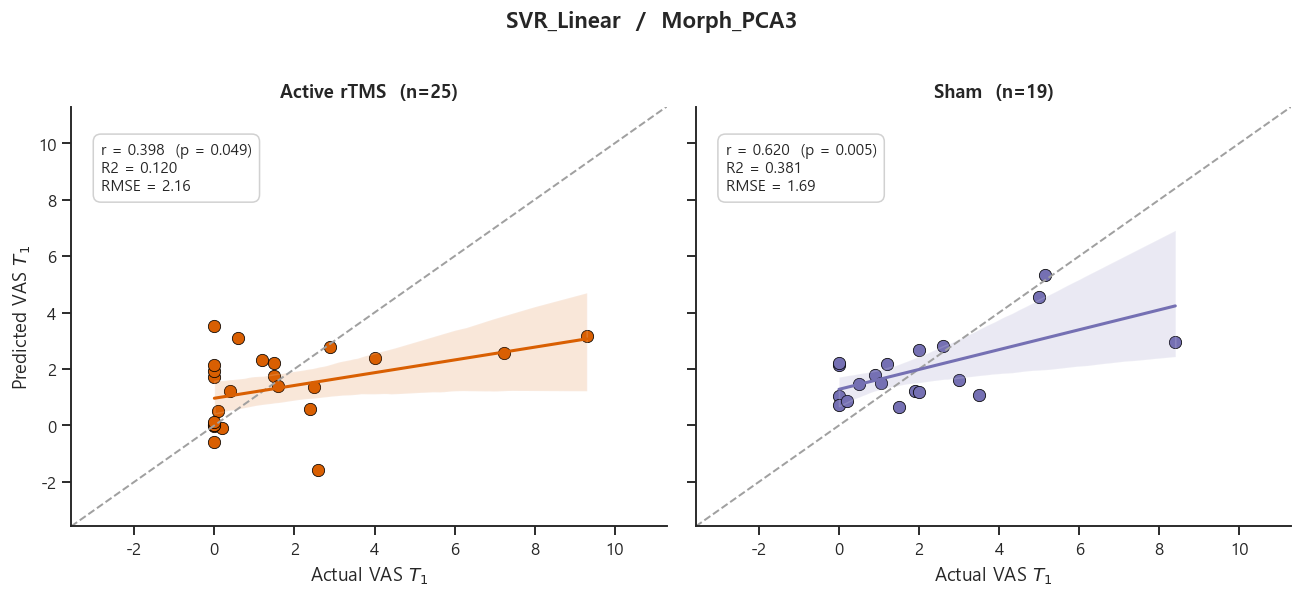

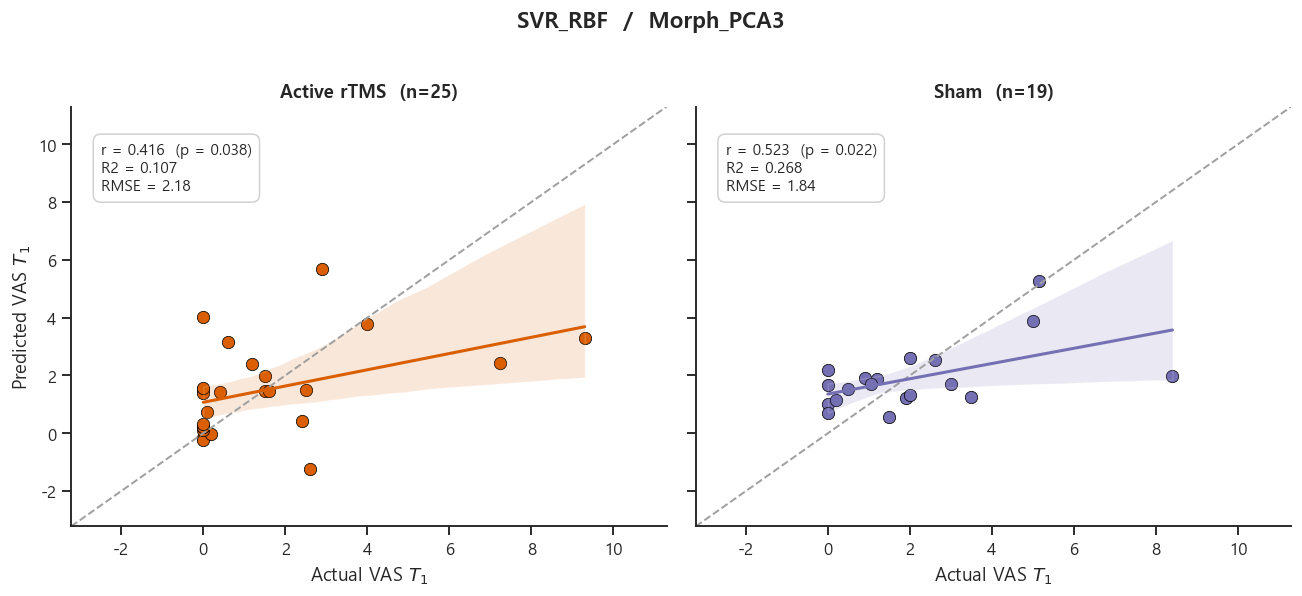

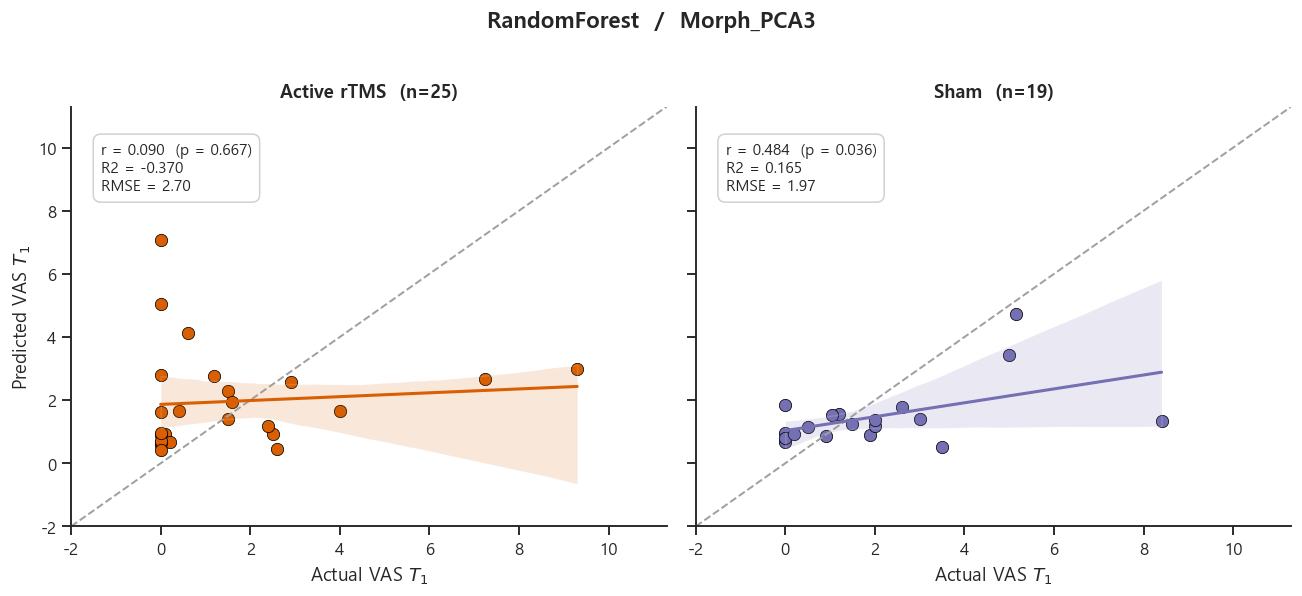

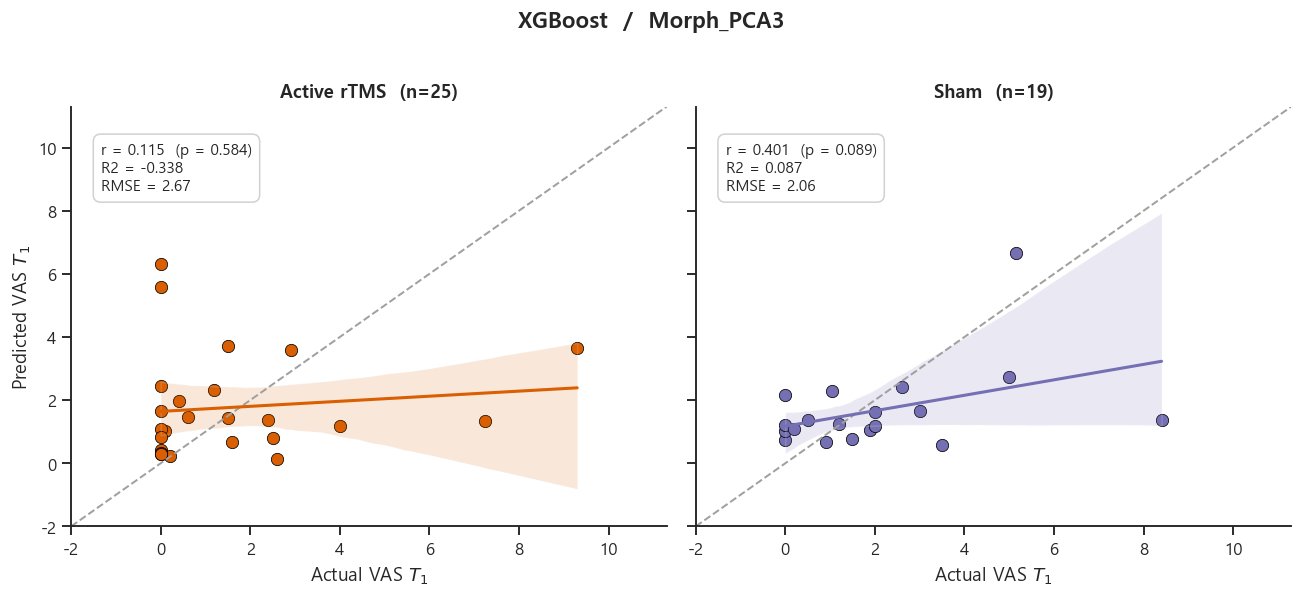

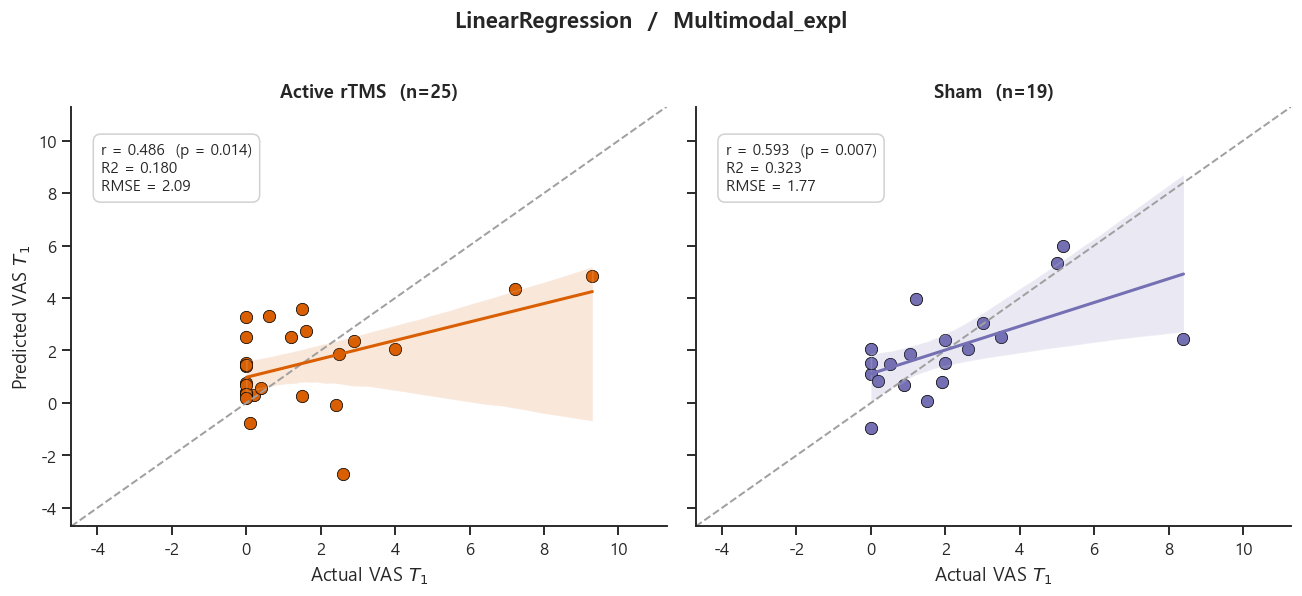

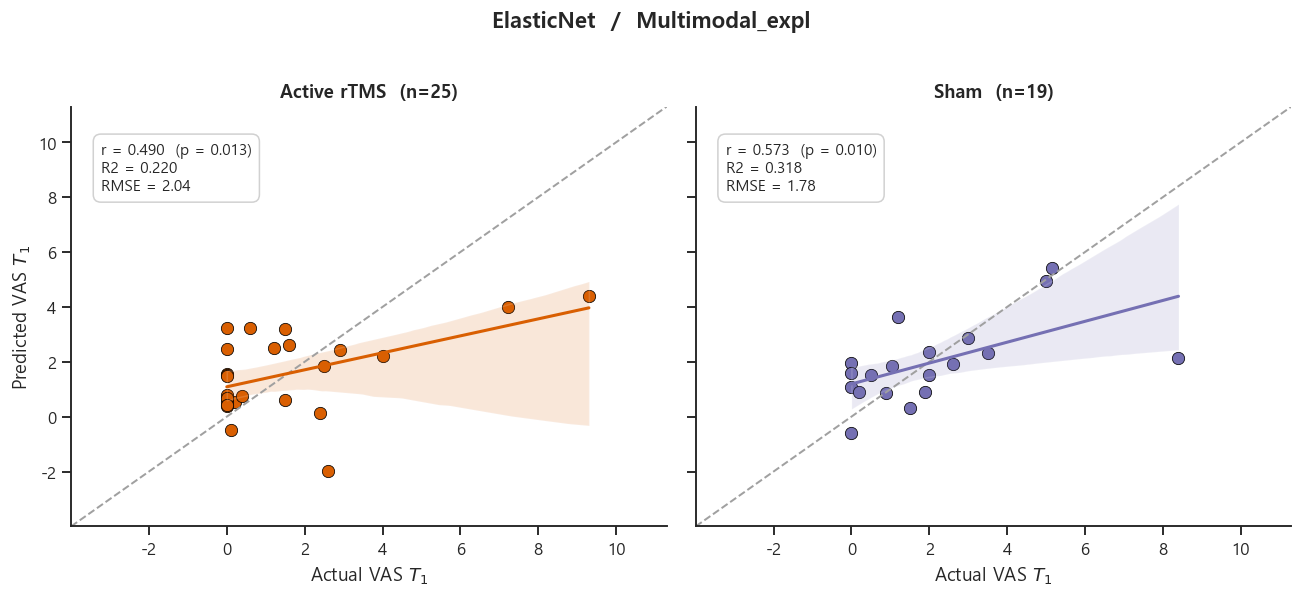

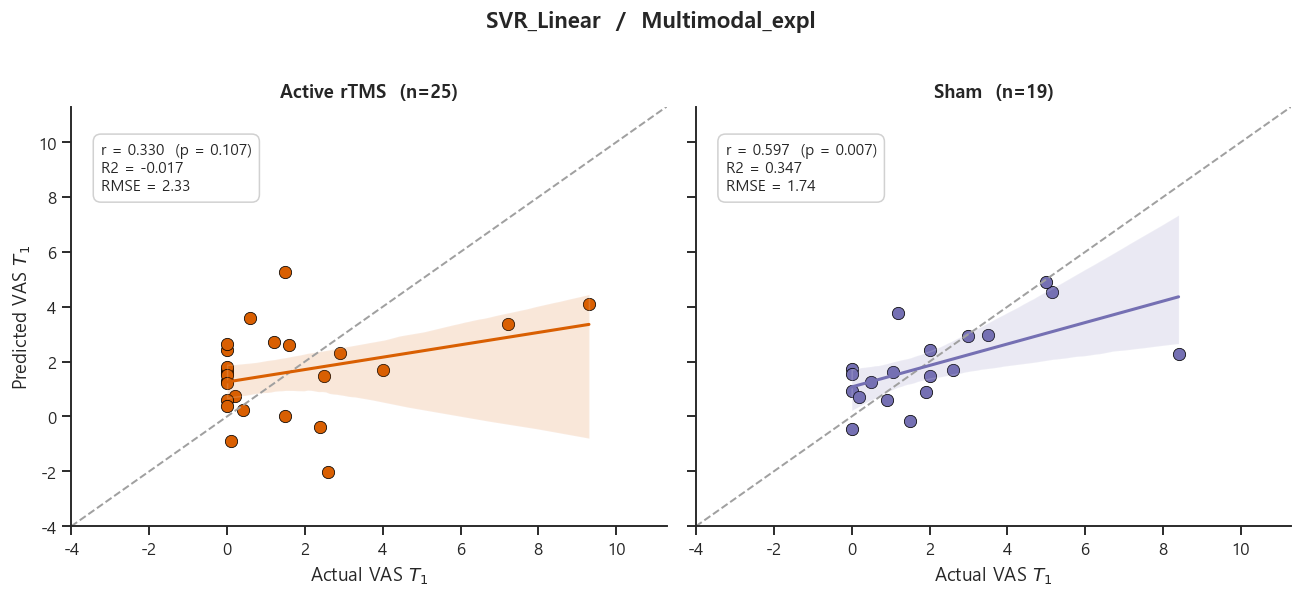

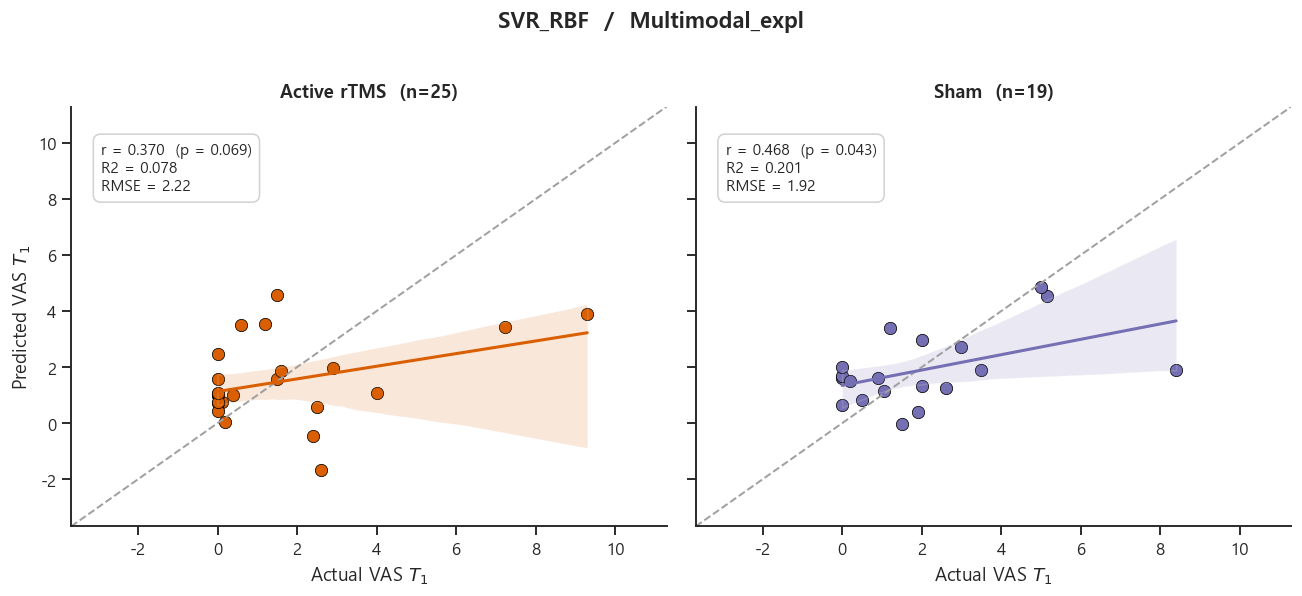

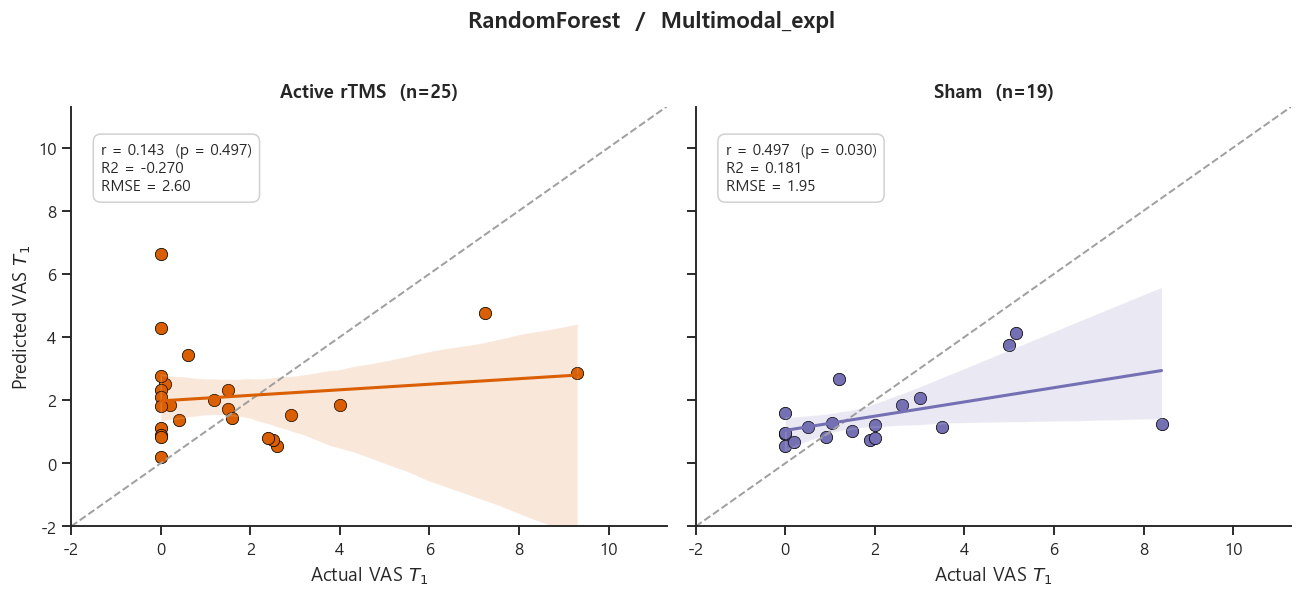

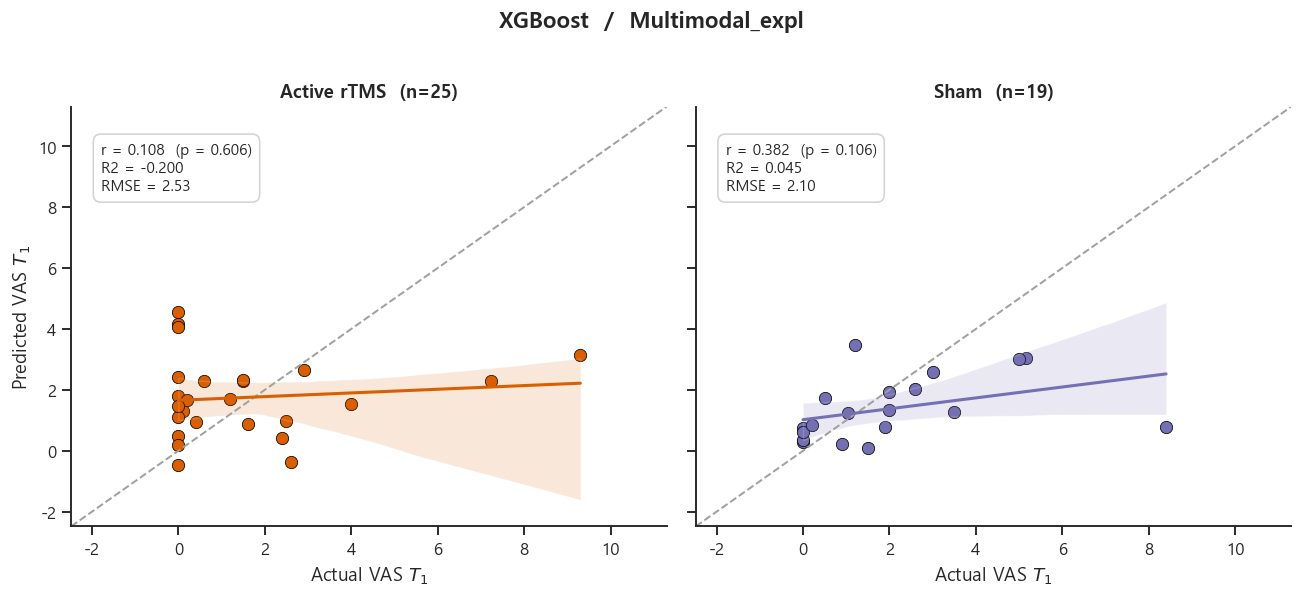

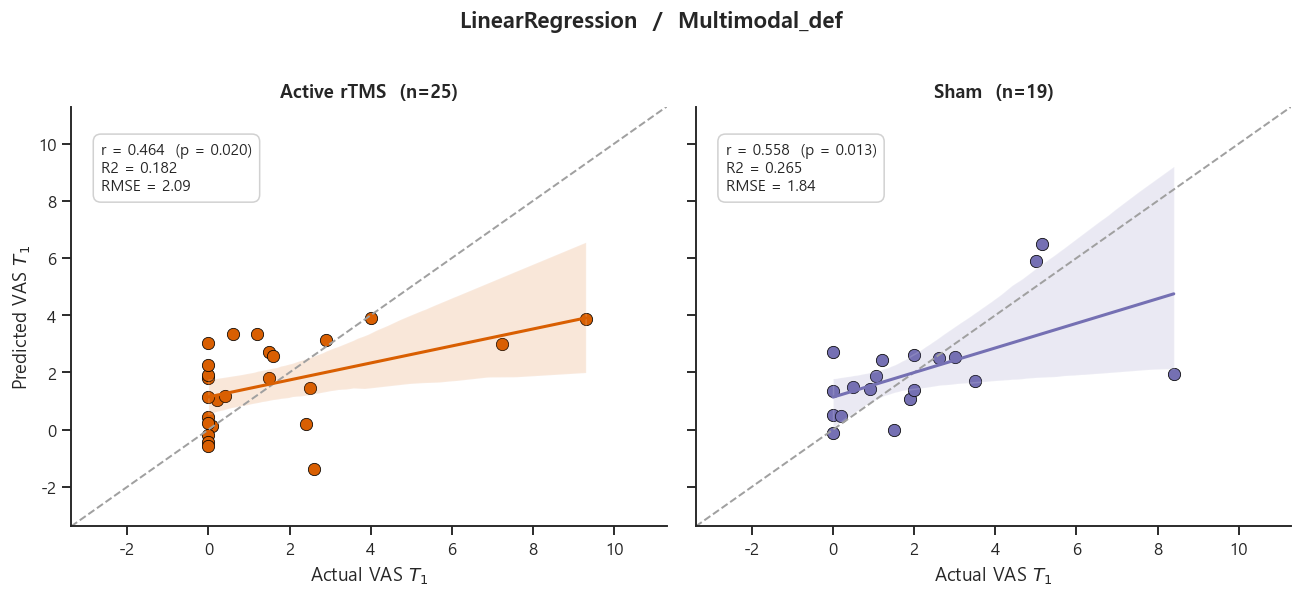

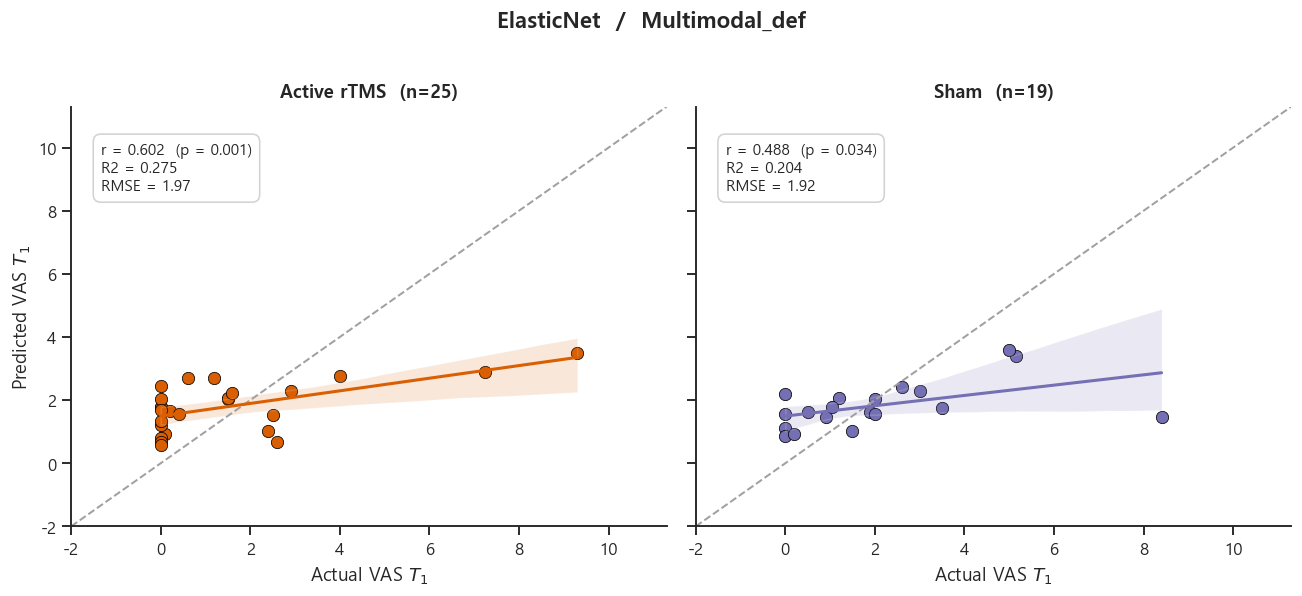

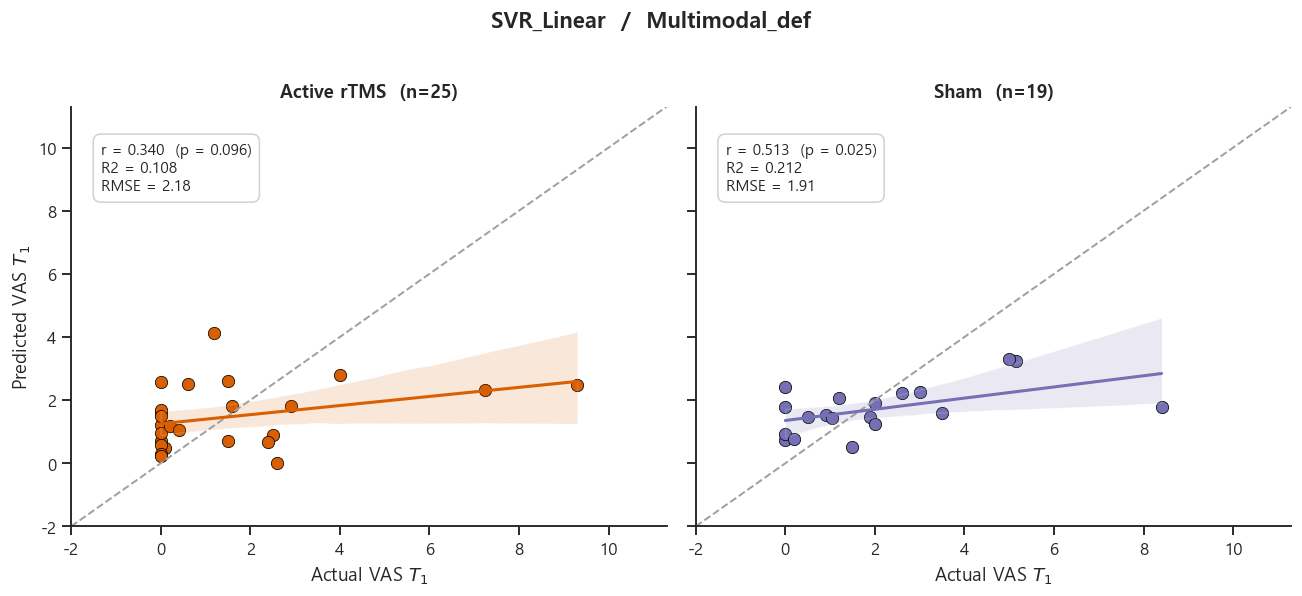

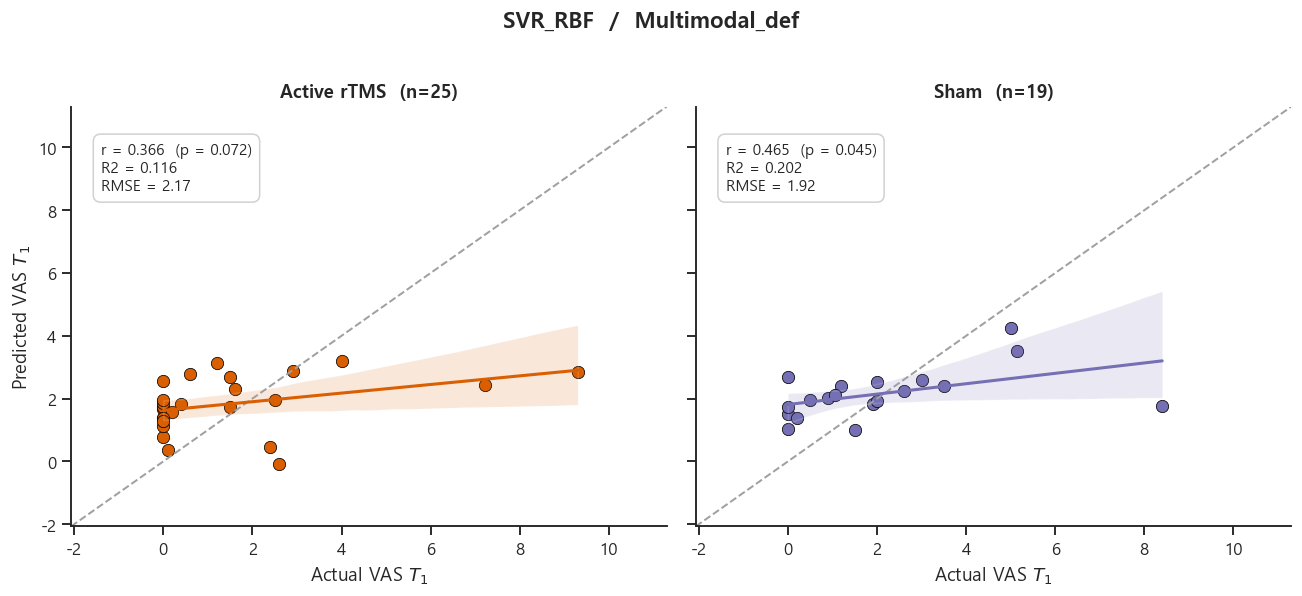

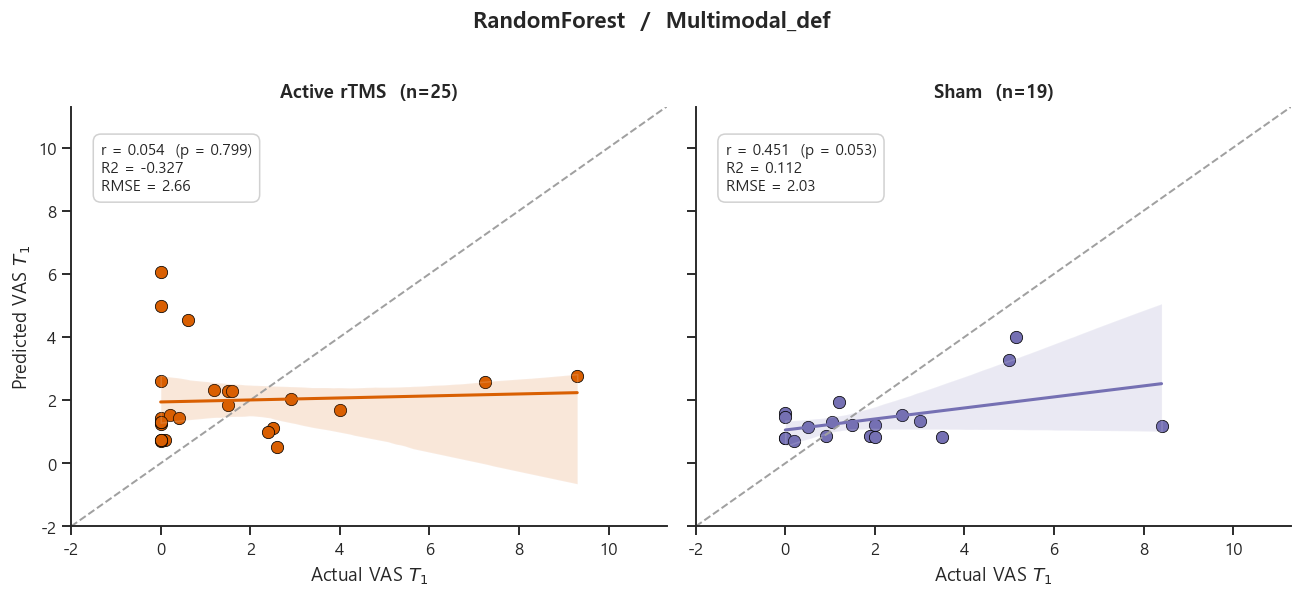

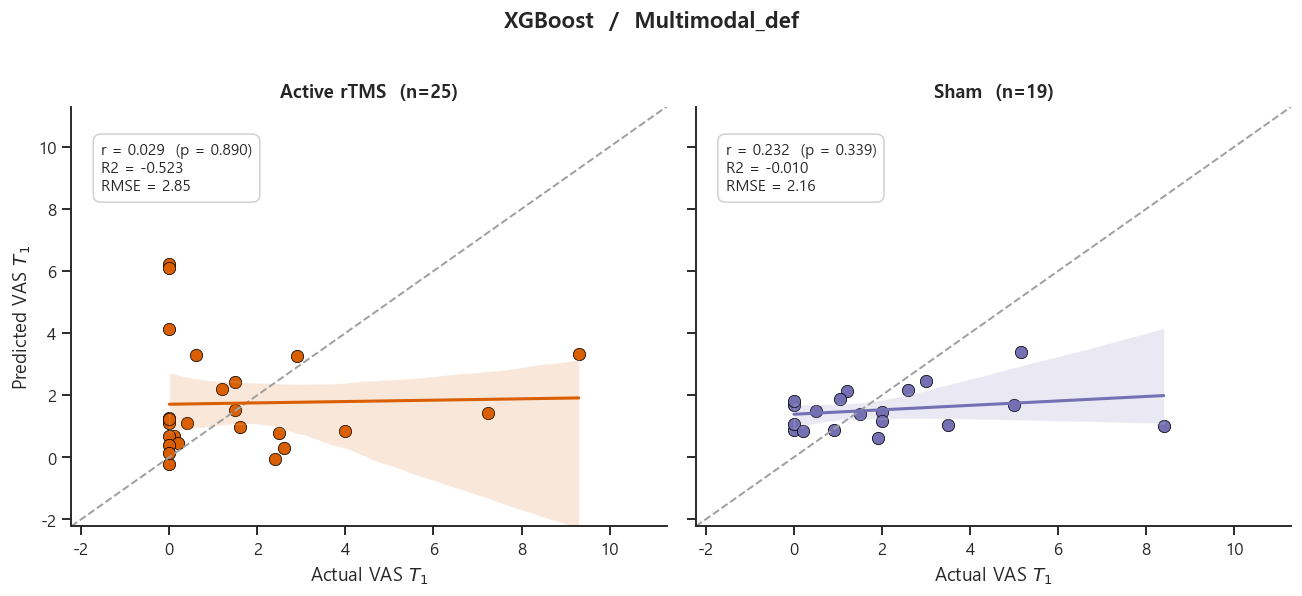

In [9]:
# ==========================================================
# 8. 산점도 (선택) — multimodal 위주
# ==========================================================
PLOT_DATA_TYPES = ['Morph_PCA3', 'Multimodal_expl', 'Multimodal_def']
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for (dt, name), preds in predictions.items():
    if dt not in PLOT_DATA_TYPES:
        continue
    yp = np.array(preds)
    pdf = pd.DataFrame({'Actual': y, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

## 결과 읽는 법

1. **정직한 판정**: `Multimodal_def` vs `Morph_PCA3` vs `Clinical_ONLY` (전부 같은 44명, leakage 없음).
   - `Multimodal_def` 가 `Morph_PCA3` 보다 확실히 낮으면 → FC가 morph에 직교하는 신호를 더한 것.
   - 비슷하면 → FC는 기여 없음, morph PCA(3)가 캐리.
2. **`Multimodal_expl`** (FC SHAP Top-2): 여기만 확 낮아지면 selection leakage 신호.
   독립표본에서 재현되기 전에는 결과로 인용하지 말 것.
3. `d_*` 열이 + 이고 6개 모델 중 몇 개에서 일관적인지 확인.
   선형/커널(EN, LR, SVR)에서 일관 → 신뢰도 ↑ / 트리(RF, XGB)만 → 노이즈 가능성.
4. 기준선: 같은 44명에서 `Clinical_ONLY` best ≈ RMSE 2.0 (FC 노트북 값), 평균예측 = 2.31.
   morph 단독 노트북의 2.05는 n=45라 여기 44명 재실행값과 다름 — 비교는 이 노트북 안에서만.
